# GTEx + AHBA Tensor Slices — On-Brain Views

Loads the **full** TensorViews (all genes / all subjects), then renders one
`(subject, gene)` slice two ways on a shared color scale:

1. **nilearn** glass-brain dots (parcel MNI centroid → colored marker)
2. **yabplot** cortical / subcortical surfaces (`cortical`, `subcortical_cerebellar`, `joint`)

All rendering logic lives in `src/eval_utils/eval_onbrain.py` — this notebook is
**config-first**: each numbered section opens with a toggle block, then one call.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.results_eda import EDAConfig
from src.eval_utils.eval_samples import (
    MatchingContext, build_combat_tensor_view, build_prediction_tensor_view,
)
from src.eval_utils import eval_onbrain as ob

set_academic_style()

## 1 · Data & load settings
*Toggle:* model / gene scope, matching policy, and how much to load (`None` = everything).

In [2]:
# ---- data source ----
CACHE_ROOT = 'out/loro_subject_cache_cv_shrink'   # _cv = centroids_and_volumes
MODEL_NAME = 'dlam'                         # 'naive' | 'dlam' | 'plam'
GENE_SCOPE = 'allgenes'                     # 'allgenes' | 'hvg'
CSV_PATH   = 'data/raw/gxp_samples.csv'

# ---- matching / harmonization ----
MATCHING_POLICY           = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE             = 'centroid'
GTEX_HEMI_MODE            = 'mirror_left'
COLLAPSE_CEREBELLUM       = False
MIN_OBSERVED_PARCELS      = 5
COMBAT_USE_COVARIATES     = True

# ---- how much to load (None = everything; set to cap memory/time) ----
REGION_ORDERING  = 'region_matched_superset'
ACTIVE_GENE_LIST = None     # None = all ~11.7k genes | a panel name e.g. 'richiardi2015'
N_GENES          = None     # None = all
N_GTEX_SUBJECTS  = None     # None = all GTEx subjects in the cache (~318)
N_AHBA_SUBJECTS  = None     # None = all AHBA donors
N_REGIONS        = None     # None = full AHBA superset (~150)
RANDOM_SEED      = 42

In [3]:
cfg = EDAConfig(
    csv_path=CSV_PATH, cache_root=CACHE_ROOT, gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS, combat_use_covariates=COMBAT_USE_COVARIATES,
    gtex_rep_mode=GTEX_REP_MODE, gtex_hemi_mode=GTEX_HEMI_MODE,
    matching_policy=MATCHING_POLICY, matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    collapse_cerebellum=COLLAPSE_CEREBELLUM,
)
prepost = prepare_pre_post_harmonization_cached(cfg)
ctx = MatchingContext.from_cfg(cfg, prepost)
tier_b = dict(cfg=cfg, matching_context=ctx, region_ordering=REGION_ORDERING,
              gene_panel=ACTIVE_GENE_LIST, n_regions=N_REGIONS, n_genes=N_GENES, random_seed=RANDOM_SEED)

# subjects=None -> stack every npz (full subject axis). First build is slow (~minutes).
ahba_h     = build_combat_tensor_view(prepost, dataset='AHBA', stage='harmonized', n_subjects=N_AHBA_SUBJECTS, **tier_b)
gtex_truth = build_prediction_tensor_view(CACHE_ROOT, MODEL_NAME, dataset='GTEx', stage='loro_truth', subjects=None, n_subjects=N_GTEX_SUBJECTS, **tier_b)
gtex_recon = build_prediction_tensor_view(CACHE_ROOT, MODEL_NAME, dataset='GTEx', stage='loro_recon', subjects=None, n_subjects=N_GTEX_SUBJECTS, **tier_b)
gtex_fused = build_prediction_tensor_view(CACHE_ROOT, MODEL_NAME, dataset='GTEx', stage='loro_fused', subjects=None, n_subjects=N_GTEX_SUBJECTS, **tier_b)

assert gtex_truth.regions == gtex_recon.regions == gtex_fused.regions == ahba_h.regions
assert gtex_truth.genes == ahba_h.genes
REGION_COORDS = ob.region_coords(prepost, gtex_truth.regions)   # (n_regions, 3) MNI centroids
print(f'{len(gtex_truth.genes)} genes x {len(gtex_truth.regions)} regions | '
      f'{len(gtex_truth.subjects)} GTEx + {len(ahba_h.subjects)} AHBA subjects')

[prepost_cache] hit  notebooks/cache/prepost/b8c1d9d0503e5133.pkl  (8961.2 MB)


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:356: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


11704 genes x 150 regions | 318 GTEx + 6 AHBA subjects


## 2 · Select gene & subject
*Toggle:* `GENE`, `GTEX_SUBJECT`, `AHBA_SUBJECT`. Use `ob.search(...)` to look names up. `CLIM_PCT` sets the shared color limits used by both rows.

In [4]:
CLIM_PCT     = (2.0, 98.0)                # robust shared color limits
GENE         = 'SIX3' # gtex_truth.genes[0]        # any gene name  -> ob.search(gtex_truth.genes, 'GABR')
GTEX_SUBJECT = gtex_truth.subjects[1]     # any GTEx id     -> ob.search(gtex_truth.subjects, '11')
AHBA_SUBJECT = ahba_h.subjects[0]         # any AHBA donor id

PANELS = ob.build_panels(MODEL_NAME, gtex_truth, gtex_recon, gtex_fused, ahba_h, GTEX_SUBJECT, AHBA_SUBJECT)
VMIN, VMAX = ob.shared_clim([ob.subject_gene_values(v, s, GENE) for _, v, s in PANELS], pct=CLIM_PCT)
print(f'gene={GENE!r}  shared clim=({VMIN:.3f}, {VMAX:.3f})')
for title, v, s in PANELS:
    print(f'  {title.splitlines()[0]:30s} {int(np.isfinite(ob.subject_gene_values(v, s, GENE)).sum()):3d} parcels')

gene='SIX3'  shared clim=(2.183, 7.748)
  DLAM — held-out truth           11 parcels
  DLAM — LORO recon               11 parcels
  DLAM — LORO fused              150 parcels
  AHBA reference                 137 parcels


## 3 · nilearn glass-brain dots
**What each panel shows:** one colored marker per parcel at its MNI centroid, for the selected
`(GENE, subject)`. The four panels share one color scale (`CLIM_PCT`) so they're directly comparable:

| panel | source | subject |
|---|---|---|
| held-out truth | `gtex_truth` (LORO) | `GTEX_SUBJECT` |
| LORO recon | `gtex_recon` | `GTEX_SUBJECT` |
| LORO fused | `gtex_fused` | `GTEX_SUBJECT` |
| AHBA reference | `ahba_h` (harmonized) | `AHBA_SUBJECT` |

*Toggle:* colormap, projection (`x` sagittal / `z` axial / `ortho`), marker size.
*Note:* dots use raw `target_meta` coords (force-left), so right-hemisphere parcels sit on the left.

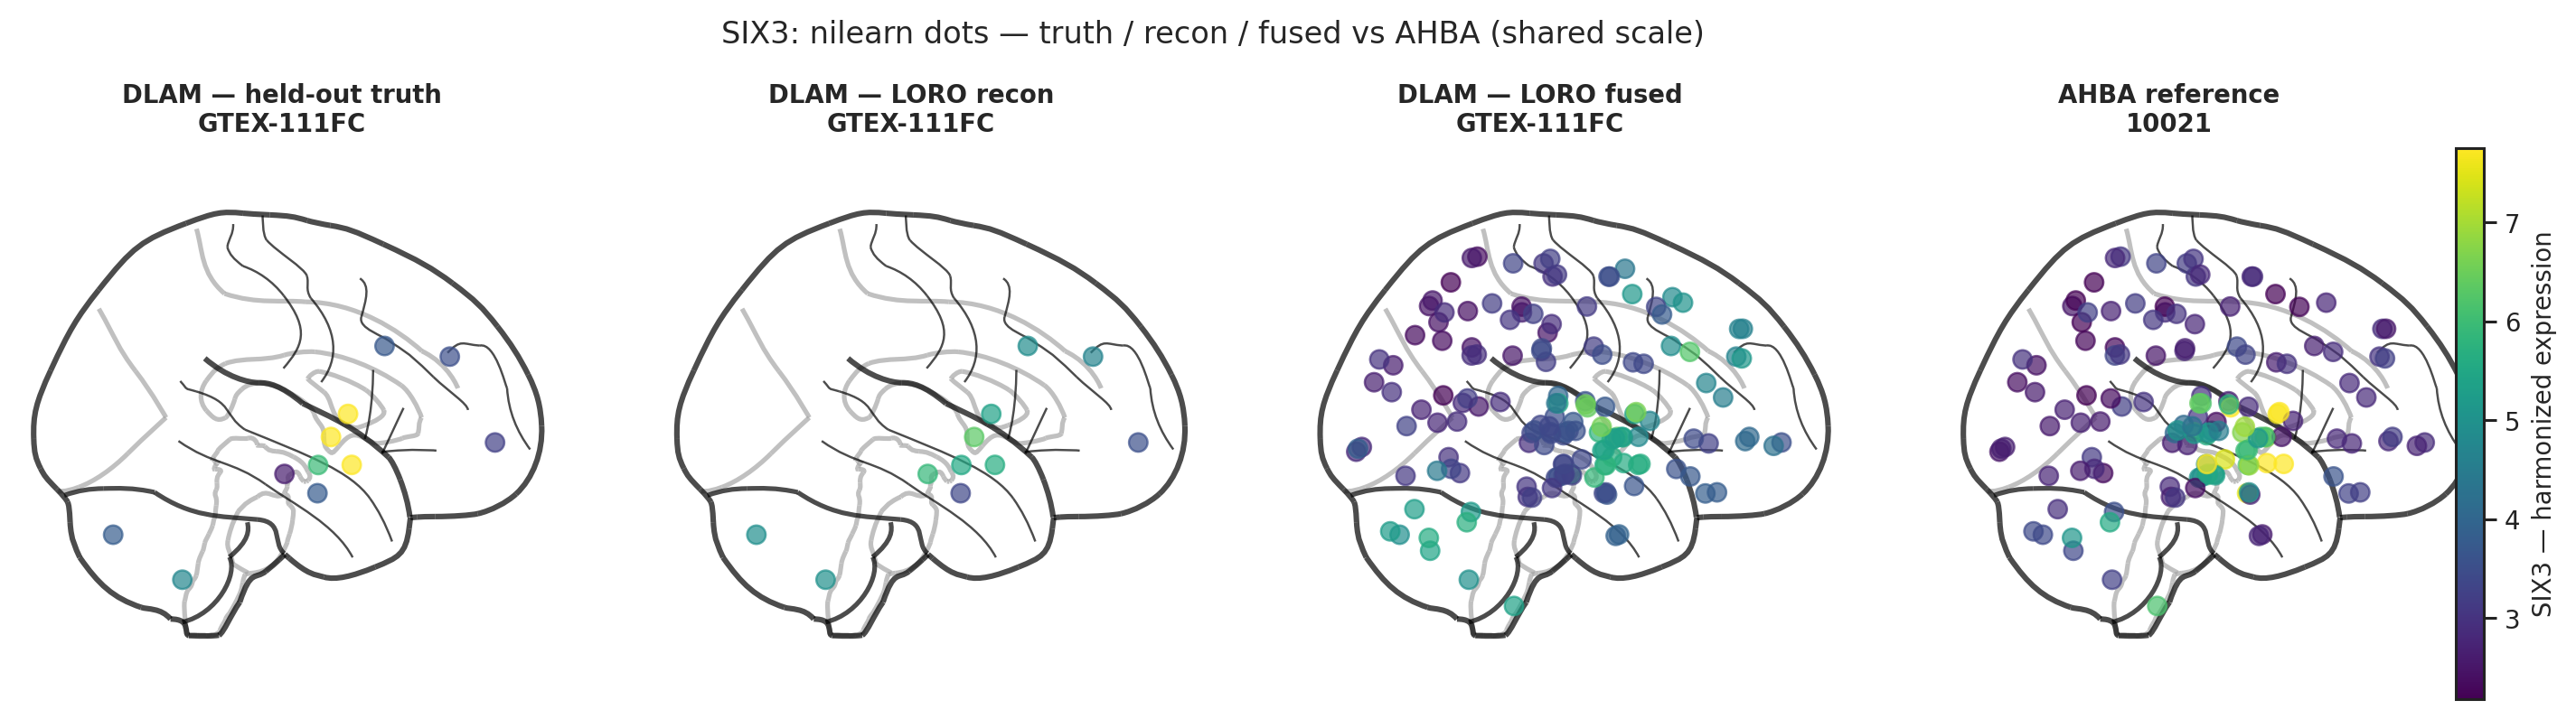

In [5]:
NL_CMAP         = 'viridis'
NL_DISPLAY_MODE = 'x'      # 'x' sagittal | 'z' axial | 'ortho' (3 cuts)
NL_NODE_SIZE    = 45

ob.render_nilearn_row(PANELS, GENE, REGION_COORDS, vmin=VMIN, vmax=VMAX,
                      cmap=NL_CMAP, display_mode=NL_DISPLAY_MODE, node_size=NL_NODE_SIZE)

## 4 · yabplot cortical-surface views
Same four `(GENE, subject)` panels as above (truth / recon / fused / AHBA ref, shared scale), but
painted on **anatomical surfaces** instead of dots. Three complementary scopes follow, each in its own
subsection. `YAB_HEMIS='both'` renders the full brain; per-scope camera/opacity live in
`ob.BrainSurfaceRenderer.SCOPE_CFG`.

*Toggle:* colormap, zoom, hemispheres, export dir.

In [10]:
YAB_CMAP    = 'viridis'
YAB_ZOOM    = 1.1
YAB_HEMIS   = 'both'               # 'both' full brain | 'left' | 'right'
EXPORT_DIR  = 'out/brain_renders'  # set to None to skip saving PNGs

brain = ob.BrainSurfaceRenderer(atlas_cache='data/brain_atlas_4s')   # loads surface + atlas once

### 4a · `cortical` — cortical surface only
Parcel values painted on the cortical sheet (lateral view). Subcortex/cerebellum hidden. Best for
reading **cortical** expression gradients. Cortex is lightly translucent so folds read clearly.

saved out/brain_renders/cortical__SIX3__GTEX-111FC.png


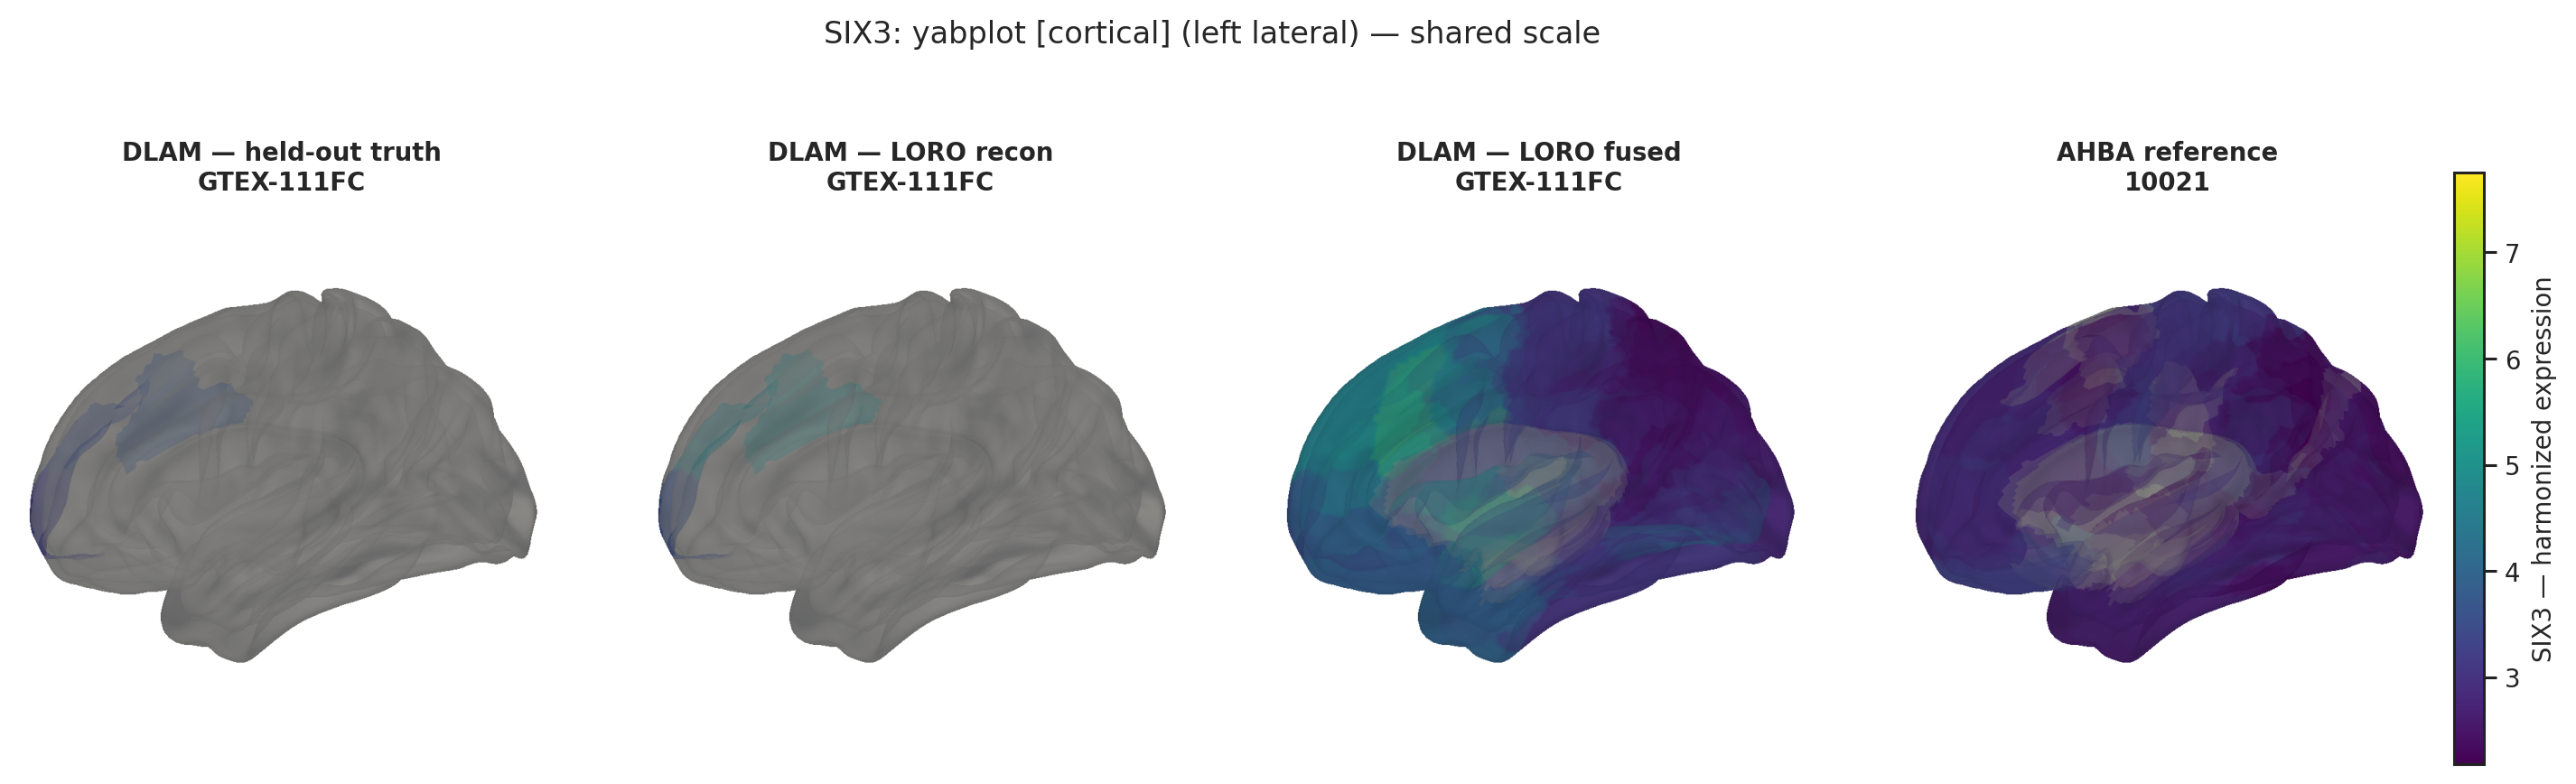

In [11]:
ob.render_scope_row(brain, 'cortical', PANELS, GENE, vmin=VMIN, vmax=VMAX, cmap=YAB_CMAP, zoom=YAB_ZOOM, hemispheres=YAB_HEMIS, export_dir=EXPORT_DIR)

### 4b · `subcortical_cerebellar` — subcortex + cerebellum
Subcortical and cerebellar structures shown as solid colored meshes inside a **translucent cortical
shell** (for spatial context only — the cortex carries no data here). Best for reading **deep / cerebellar** values.

saved out/brain_renders/subcortical_cerebellar__SIX3__GTEX-111FC.png


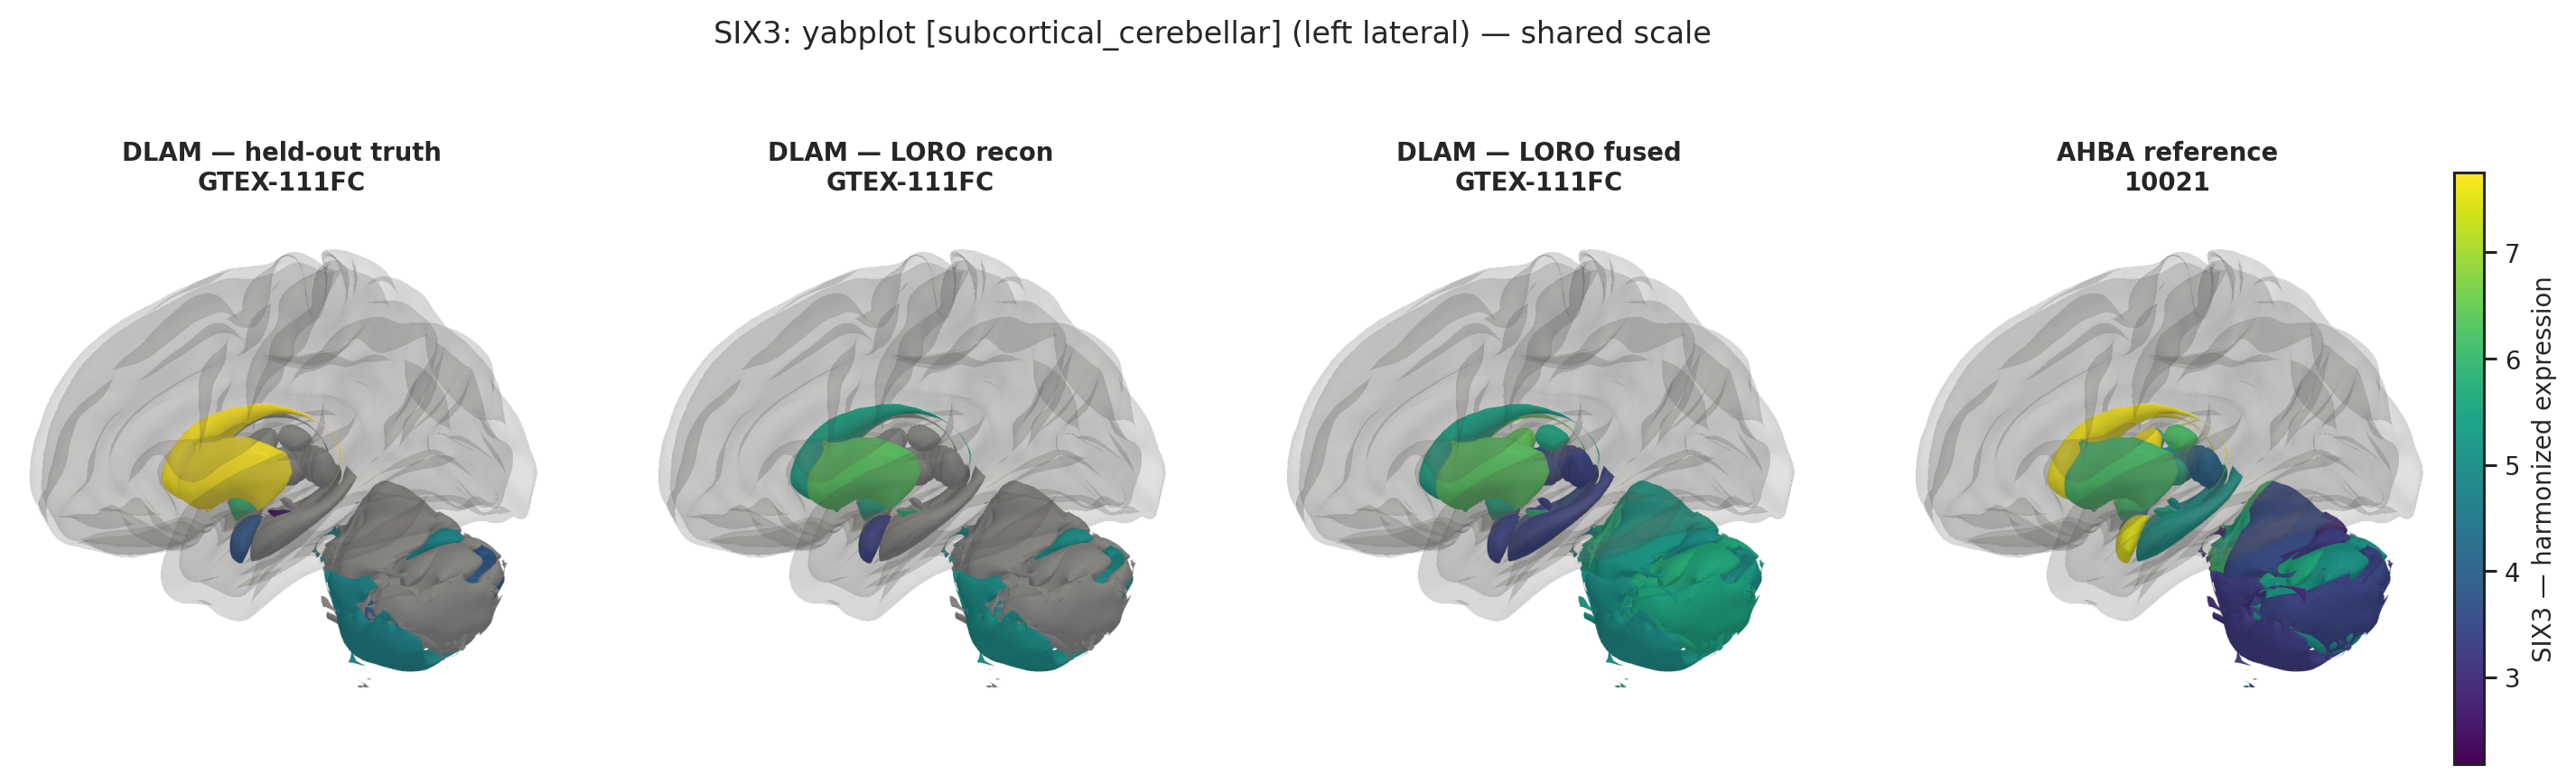

In [12]:
ob.render_scope_row(brain, 'subcortical_cerebellar', PANELS, GENE, vmin=VMIN, vmax=VMAX, cmap=YAB_CMAP, zoom=YAB_ZOOM, hemispheres=YAB_HEMIS, export_dir=EXPORT_DIR)

### 4c · `joint` — cortex + subcortex together  *(in progress)*
Both cortical data **and** subcortical meshes in one scene, **left hemisphere only**, viewed on the
**left lateral** surface (anterior left, posterior right). **Sampled** cortical parcels render clear/opaque;
**unsampled** cortex fades to a translucent shell (like 4b) so the deep structures and sampled regions
stand out. Whole-hemisphere overview in a single panel.

saved out/brain_renders/joint__SIX3__GTEX-111FC.png


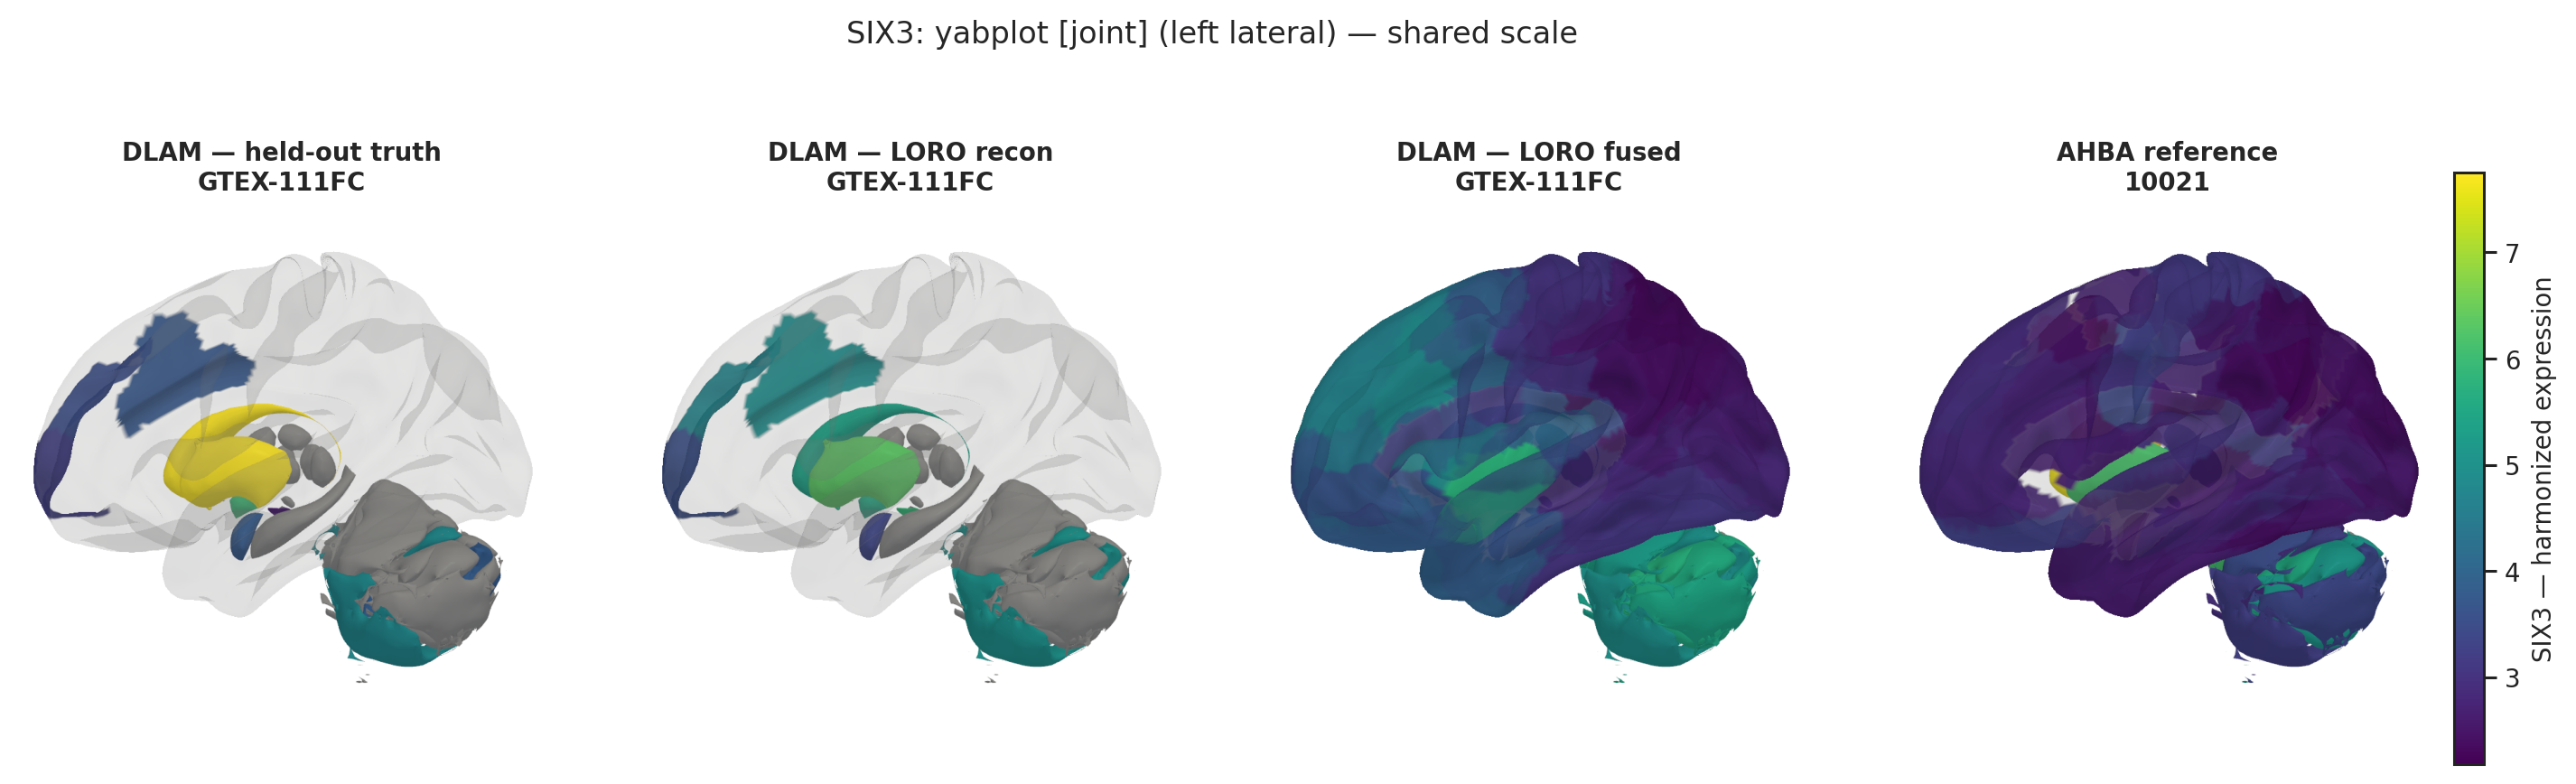

In [13]:
ob.render_scope_row(brain, 'joint', PANELS, GENE, vmin=VMIN, vmax=VMAX, cmap=YAB_CMAP, zoom=YAB_ZOOM, hemispheres='left', export_dir=EXPORT_DIR)